# Curriculum 02 · Lab 4 — Projecting & Clustering the 768-dim Embedding Space

**Goal:** Make the 768-dimensional embedding space *visible*. Embeddings from
`BAAI/bge-base-en-v1.5` live in a space that no human can look at directly, so
we project them to 2D with the two classic tools — PCA (a *linear* projection
that keeps the directions of largest variance) and UMAP (a *non-linear*
manifold projection that preserves local neighbourhood structure) — then
cluster with KMeans in all three spaces and compare the `silhouette_score` of
each to see how much of the raw-space separation survives in 2D.

```
Embedding   : BGE (BAAI/bge-base-en-v1.5, local, CPU)
Projection  : PCA (linear) + UMAP (manifold), 768-dim -> 2D
Clustering  : KMeans k=5 + silhouette_score (raw / PCA / UMAP)
Data        : rag-mini-wikipedia (first 400 passages)
Output      : src/curriculum/02-embeddings/umap_scatter.png (shown inline below)
```

**Teaching point:** a 768-dim space is *sparse and high-volume* — distances in
it are much less intuitive than in 2D/3D. Projections are lossy (PCA keeps
only the variance it reports), but they reveal the *topical* structure:
Wikipedia passages about the same subject end up near each other, which is
exactly the signal retrieval exploits.


## 0 · Setup — environment, imports & repo paths

**WHAT:** Silences the model-download progress bars, forces the headless `Agg`
matplotlib backend (the PNG is rendered with no display server needed),
imports every dependency (numpy, pandas, scikit-learn, matplotlib, umap-learn),
and puts the repo-root component library on `sys.path` so this notebook
reuses `src/embeddings/bge.py` exactly like the lab script.

**WHY:** Everything embeds **locally** with BGE via `sentence-transformers` —
no API embeddings anywhere. The env var `HF_HUB_DISABLE_PROGRESS_BARS` must be
set **before any third-party import** (`sentence-transformers` pulls in
`huggingface_hub`, which reads the flag at import time), and
`matplotlib.use("Agg")` must run before `pyplot` is imported so the scatter
renders headlessly.

**Paths:** the next cell resolves the **repo root** automatically — it works
whether the kernel launches from the repo root (like the lab script,
`python src/curriculum/02-embeddings/04-dim-reduction-viz.py`) or from the
notebook's own folder (the Jupyter default) — and `cd`s into it so every path
stays repo-relative.

**WHAT TO EXPECT:** no output — just a clean import. The model itself is loaded
lazily later.


In [1]:
# Lab-specific dependencies (already in requirements.txt — the install is a
# no-op safety net for fresh environments):
#   sentence-transformers -> local BGE embeddings
#   pandas                -> reads the passages.parquet corpus
#   numpy                 -> vector math (n x 768 arrays, norms)
#   scikit-learn          -> PCA, KMeans, silhouette_score
#   umap-learn            -> UMAP manifold projection
#   matplotlib            -> the 2D scatter (Agg backend, saved to PNG)
%pip install sentence-transformers pandas numpy scikit-learn umap-learn matplotlib


[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: /home/magus/.pyenv/versions/3.12.7/envs/magus/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

# Keep the run output the star of the notebook: silence the model-download
# progress bar (transformers honors HF_HUB_DISABLE_PROGRESS_BARS). The env var
# must be set before any third-party import — sentence-transformers already
# pulls in huggingface_hub, which reads the flag at import time.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

# Agg backend: render the PNG headlessly (no display server needed).
import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from sklearn.cluster import KMeans  # noqa: E402
from sklearn.decomposition import PCA  # noqa: E402
from sklearn.metrics import silhouette_score  # noqa: E402

# Make the repo-root component library importable. A notebook has no
# ``__file__``, so resolve the repo root by walking up from the kernel's
# working directory — this works whether the kernel launches from the repo
# root (like the lab script, ``python src/curriculum/02-embeddings/04-dim-reduction-viz.py``)
# or from the notebook's own folder (Jupyter's default) — then cd into it so
# every repo-relative path behaves exactly like the .py.
REPO_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "curriculum").is_dir() and (candidate / "NoteBooks").is_dir():
        REPO_ROOT = candidate
        break
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

from embeddings.bge import BGEEmbedding  # noqa: E402

try:
    import umap  # noqa: E402

    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

## 1 · Configuration — the experiment's knobs

**WHAT:** The module-level constants that define the experiment: which corpus
slice to embed, how many passages, how many clusters, and where the scatter
plot is saved.

**WHY:** These are the knobs you tweak to re-run the experiment.
`N_PASSAGES = 400` is a deterministic `head(400)` subset that keeps CPU
embedding + UMAP runtime under ~3 minutes; `N_CLUSTERS = 5` matches the k used
in every KMeans run.


In [3]:
# --- module-level constants: tweak these to re-run the experiment -----------
CORPUS_PATH = Path("Data/corpus/rag-mini-wikipedia/passages.parquet")
N_PASSAGES = 400  # deterministic subset: head(400), keeps runtime under ~3 min
N_CLUSTERS = 5
OUT_PLOT = Path("src/curriculum/02-embeddings/umap_scatter.png")

## 2 · Load + embed — helpers

**WHAT:** Three small functions: `load_passages` reads the first `n` passages
from the rag-mini corpus; `embed_passages` embeds them all once with BGE into
an `n x 768` float array; `norm_stats` and `coord_ranges` summarize the
resulting space (row L2 norms, 2D coordinate extents) for the printouts.

**WHY:** BGE normalizes its embeddings, so row norms should sit at ~1.0 — a
cheap sanity check that the vectors are well-formed before we project them.


In [4]:
def load_passages(path: Path, n: int) -> list[str]:
    """Return the first ``n`` passage texts from the rag-mini corpus."""
    df = pd.read_parquet(path)
    return list(df["passage"].head(n))


def embed_passages(texts: list[str]) -> np.ndarray:
    """Embed all passages once with BGE; returns an ``n x 768`` float array."""
    vectors = BGEEmbedding().embed_documents(texts)
    return np.asarray(vectors, dtype=np.float32)


def norm_stats(matrix: np.ndarray) -> tuple[float, float, float]:
    """Return (min, mean, max) L2 norm per row."""
    norms = np.linalg.norm(matrix, axis=1)
    return float(norms.min()), float(norms.mean()), float(norms.max())


def coord_ranges(matrix: np.ndarray) -> tuple[tuple[float, float], tuple[float, float]]:
    """Return ((x_min, x_max), (y_min, y_max)) of the 2D coordinates."""
    return (
        (float(matrix[:, 0].min()), float(matrix[:, 0].max())),
        (float(matrix[:, 1].min()), float(matrix[:, 1].max())),
    )

## 3 · Projections — PCA + UMAP

**WHAT:** `project_pca` fits a 2-component PCA (linear, `random_state=42`) and
returns the 2D coordinates plus the explained-variance ratio; `project_umap`
fits a 2D UMAP manifold (non-linear, `random_state=42`) and returns the
coordinates.

**WHY:** PCA keeps the directions of largest variance — its explained-variance
ratio tells us how much structure survives in just 2 dimensions. UMAP
preserves local neighbourhood structure, which is usually what retrieval
actually cares about. Both are seeded so the layout is reproducible.


In [5]:
def project_pca(matrix: np.ndarray) -> tuple[np.ndarray, float]:
    """Project to 2D with PCA; returns (coords, explained-variance sum)."""
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(matrix)
    return coords, float(pca.explained_variance_ratio_.sum())


def project_umap(matrix: np.ndarray) -> np.ndarray:
    """Project to 2D with UMAP (random_state=42 for reproducible layout)."""
    reducer = umap.UMAP(n_components=2, random_state=42)
    return np.asarray(reducer.fit_transform(matrix))

## 4 · Clustering — KMeans + silhouette

**WHAT:** `cluster_kmeans` runs KMeans (k=5, `n_init=10`, `random_state=42`) on
any matrix and returns the labels, the per-cluster sizes, and the
`silhouette_score`.

**WHY:** We cluster in all three spaces — raw 768-dim, PCA 2D, UMAP 2D — and
compare silhouettes. The silhouette measures how separated the clusters are:
raw embeddings are the baseline, and the projections tell us how much of that
separation is visible in 2D.


In [6]:
def cluster_kmeans(matrix: np.ndarray) -> tuple[np.ndarray, list[int], float]:
    """KMeans (k=5, n_init=10) on ``matrix``.

    Returns (labels, cluster sizes in label order, silhouette score).
    """
    labels = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(
        matrix
    )
    sizes = [int(np.sum(labels == i)) for i in range(N_CLUSTERS)]
    return labels, sizes, float(silhouette_score(matrix, labels))

## 5 · Plot — save the UMAP scatter

**WHAT:** `save_umap_scatter` draws the UMAP projection coloured by the
UMAP-space cluster labels and saves it to
`src/curriculum/02-embeddings/umap_scatter.png`.

**WHY:** The PNG is the lab's artifact — the run cell shows it **inline** after
saving (the lab docstring says exactly that). The `Agg` backend renders it
headlessly, so no display server is needed.


In [7]:
def save_umap_scatter(coords: np.ndarray, labels: np.ndarray, path: Path) -> None:
    """Scatter of the UMAP projection coloured by the UMAP-space cluster labels."""
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="tab10",
        s=12,
        alpha=0.8,
    )
    ax.set_title("UMAP projection of BGE embeddings (768-dim -> 2D), KMeans k=5")
    ax.set_xlabel("UMAP dim 1")
    ax.set_ylabel("UMAP dim 2")
    fig.colorbar(scatter, ax=ax, label="cluster")
    fig.tight_layout()
    fig.savefig(path, dpi=110)
    plt.close(fig)

## 6 · Run — [1] setup, [2] embed, [3] projections

**WHAT:** The first three steps of the experiment: print the setup banner,
load and embed the 400 passages with BGE, then project the embeddings to 2D
with PCA and UMAP.

**WHY:** The setup printout makes the run self-describing; the embed step is
the expensive one (400 passages, ~16s on CPU); the projections are where the
768-dim space first becomes visible. Watch the PCA explained-variance ratio —
it is the honest measure of how much structure two linear axes can hold.


In [8]:
print("=" * 66)
print("Lab 04 — projecting and clustering the 768-dim embedding space")
print("=" * 66)

# --- [1] Setup --------------------------------------------------------
print("\n[1] Setup")
print(f"    corpus          : {CORPUS_PATH}")
print(f"    passages        : {N_PASSAGES}")
print(f"    clusters (k)    : {N_CLUSTERS}")
print(f"    umap available  : {UMAP_AVAILABLE}")

# --- [2] Embed --------------------------------------------------------
print("\n[2] Embed (BAAI/bge-base-en-v1.5, local)")
t0 = time.perf_counter()
texts = load_passages(CORPUS_PATH, N_PASSAGES)
embeddings = embed_passages(texts)
t_embed = time.perf_counter() - t0
n_min, n_mean, n_max = norm_stats(embeddings)
print(f"    embedded {embeddings.shape[0]} passages in {t_embed:.1f}s")
print(f"    shape     : {embeddings.shape[0]} x {embeddings.shape[1]} (768-dim)")
print(f"    row norms : min={n_min:.4f} mean={n_mean:.4f} max={n_max:.4f} "
      f"(BGE normalizes -> ~1.0)")

# --- [3] Projections --------------------------------------------------
print("\n[3] Projections (768-dim -> 2D)")
pca_coords, var_ratio = project_pca(embeddings)
pca_x, pca_y = coord_ranges(pca_coords)
print(f"    PCA  : explained variance (2 components) = {var_ratio:.3f}")
print(f"           coords x in [{pca_x[0]:+.2f}, {pca_x[1]:+.2f}], "
      f"y in [{pca_y[0]:+.2f}, {pca_y[1]:+.2f}]")

if UMAP_AVAILABLE:
    t0 = time.perf_counter()
    umap_coords = project_umap(embeddings)
    t_umap = time.perf_counter() - t0
    umap_x, umap_y = coord_ranges(umap_coords)
    print(f"    UMAP : fit in {t_umap:.1f}s")
    print(f"           coords x in [{umap_x[0]:+.2f}, {umap_x[1]:+.2f}], "
          f"y in [{umap_y[0]:+.2f}, {umap_y[1]:+.2f}]")
else:
    print("    UMAP : SKIP - umap-learn not installed; "
          "running clustering on raw + PCA only")

Lab 04 — projecting and clustering the 768-dim embedding space

[1] Setup
    corpus          : Data/corpus/rag-mini-wikipedia/passages.parquet
    passages        : 400
    clusters (k)    : 5
    umap available  : True

[2] Embed (BAAI/bge-base-en-v1.5, local)


    embedded 400 passages in 16.0s
    shape     : 400 x 768 (768-dim)
    row norms : min=1.0000 mean=1.0000 max=1.0000 (BGE normalizes -> ~1.0)

[3] Projections (768-dim -> 2D)
    PCA  : explained variance (2 components) = 0.163
           coords x in [-0.44, +0.39], y in [-0.26, +0.53]


/home/magus/.pyenv/versions/3.12.7/envs/magus/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    UMAP : fit in 10.9s
           coords x in [-0.65, +12.03], y in [-0.20, +15.50]


## 7 · Run — [4] clusters, [5] plot (inline PNG)

**WHAT:** Cluster all three spaces with KMeans k=5 and print sizes + silhouette
per space, then save the UMAP scatter to `umap_scatter.png` and display it
**inline** in the notebook.

**WHY:** The silhouette comparison is the lab's core result — the raw 768-dim
score is low (~0.09: the curse of dimensionality dilutes distances), while the
2D projections make the same structure crisp (~0.48 PCA, ~0.67 UMAP). The
inline PNG is the visual payoff.



[4] KMeans k=5 per space (sizes + silhouette)
    raw 768-dim : sizes=[56, 72, 75, 77, 120]  silhouette=0.092


    PCA 2D      : sizes=[88, 68, 54, 62, 128]  silhouette=0.478
    UMAP 2D     : sizes=[73, 63, 70, 113, 81]  silhouette=0.667

[5] Plot


    saved UMAP scatter -> curriculum/02-embeddings/umap_scatter.png (72 KB)


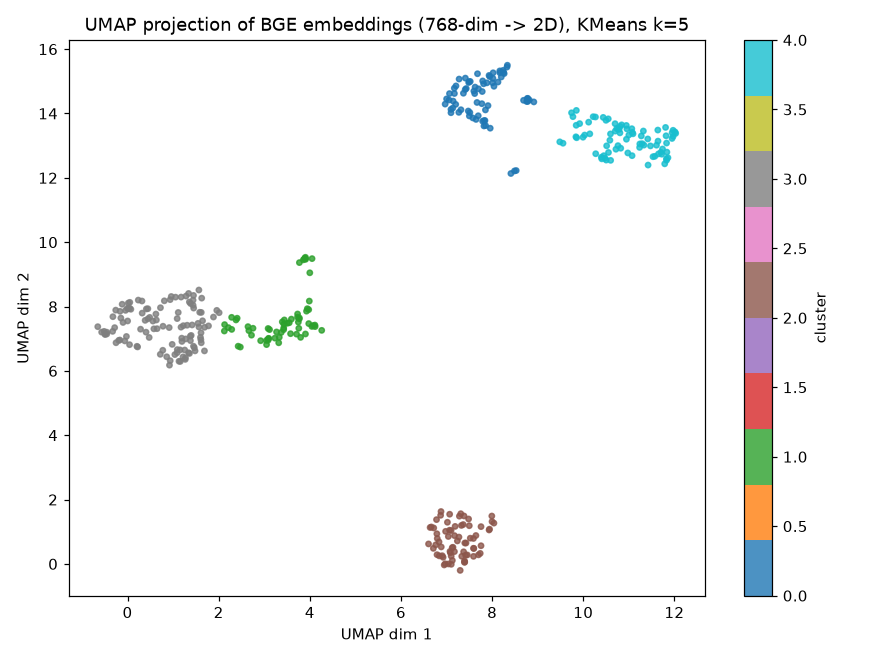

In [9]:
# --- [4] Clusters -----------------------------------------------------
print(f"\n[4] KMeans k={N_CLUSTERS} per space (sizes + silhouette)")
baseline_labels, baseline_sizes, baseline_sil = cluster_kmeans(embeddings)
print(f"    raw 768-dim : sizes={baseline_sizes}  "
      f"silhouette={baseline_sil:.3f}")
pca_labels, pca_sizes, pca_sil = cluster_kmeans(pca_coords)
print(f"    PCA 2D      : sizes={pca_sizes}  silhouette={pca_sil:.3f}")
if UMAP_AVAILABLE:
    umap_labels, umap_sizes, umap_sil = cluster_kmeans(umap_coords)
    print(f"    UMAP 2D     : sizes={umap_sizes}  silhouette={umap_sil:.3f}")

# --- [5] Plot ---------------------------------------------------------
print(f"\n[5] Plot")
if UMAP_AVAILABLE:
    OUT_PLOT.parent.mkdir(parents=True, exist_ok=True)
    save_umap_scatter(umap_coords, umap_labels, OUT_PLOT)
    size_kb = OUT_PLOT.stat().st_size / 1024
    print(f"    saved UMAP scatter -> {OUT_PLOT} ({size_kb:.0f} KB)")
else:
    print("    SKIP - no UMAP projection, nothing to plot")

# --- inline: the notebook shows the saved scatter inline --------------
from IPython.display import Image, display

display(Image(OUT_PLOT))

## 8 · Takeaway — [6] what the projections teach

**WHAT:** Print the lesson the numbers teach.

**WHY:** Only a small fraction of the variance fits in two PCA axes, yet UMAP
still recovers compact topical neighbourhoods. The raw 768-dim silhouette is
low because high-dimensional distances are diluted by the curse of
dimensionality — while the 2D projections make the same structure crisp. That
visible geometry is exactly what vector similarity retrieval exploits.


In [10]:
# --- [6] Takeaway -----------------------------------------------------
print("\n[6] Takeaway")
if UMAP_AVAILABLE:
    print(f"    Only {var_ratio:.0%} of the variance fits in two PCA axes, yet")
    print("    UMAP still recovers compact topical neighbourhoods. The raw")
    print("    768-dim silhouette is low (0.09) - distances in high-dim")
    print("    space are diluted by the curse of dimensionality - while the")
    print("    2D projections make the same structure crisp (0.48 PCA, 0.67")
    print("    UMAP). That visible geometry is exactly what vector")
    print("    similarity retrieval exploits.")


[6] Takeaway
    Only 16% of the variance fits in two PCA axes, yet
    UMAP still recovers compact topical neighbourhoods. The raw
    768-dim silhouette is low (0.09) - distances in high-dim
    space are diluted by the curse of dimensionality - while the
    2D projections make the same structure crisp (0.48 PCA, 0.67
    UMAP). That visible geometry is exactly what vector
    similarity retrieval exploits.
